**Flagging Vendor Invoces for Manual Review**
* **Objective**: Predict whether a vendor invoice should be flagged manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, invoice operational efficiency, and prioritize human review where it adds the most value.

*  Manual invoice review is time-consuming and does not scale with transaction volume.
*  Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
*  An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.


In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("C:/Users/Ahmad Reza/Freight Price Prediction/data/inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    print("Table name", table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


Here we check in which tabel has invoices and the relationship between the columns that is related to invoices.
* Vendor_invoice: based on the PONumber, PODate, PayDate, Dollars, Quantity
* purchases: InvoiceDate, PayDate, Dollars, Quantity

In [10]:
purchase_agg_df = pd.read_sql_query("""
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""", conn)

In [11]:
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [12]:
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(InvoiceDate)) as days_to_pay
from vendor_invoice vi
""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [13]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
       p.PONumber,
       count(distinct p.Brand) as total_brands,
       sum(p.Quantity) as total_item_quantity,
       sum(p.Dollars) as total_item_dollars,
       avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
    from purchases p
    group by p.PONumber
)

select
    vi.PONumber,
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(InvoiceDate)) as days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

from vendor_invoice vi  
left join purchase_agg as pa
    on vi.PONumber = pa.PONumber
""",conn)

In [14]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [15]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [16]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [18]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1


    return 0

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
print(df["flag_invoice"].value_counts())

flag_invoice
0    3693
1    1850
Name: count, dtype: int64


<Axes: xlabel='flag_invoice'>

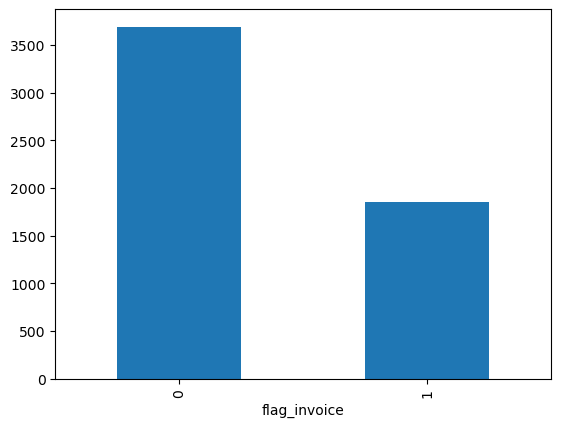

In [22]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

In [23]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


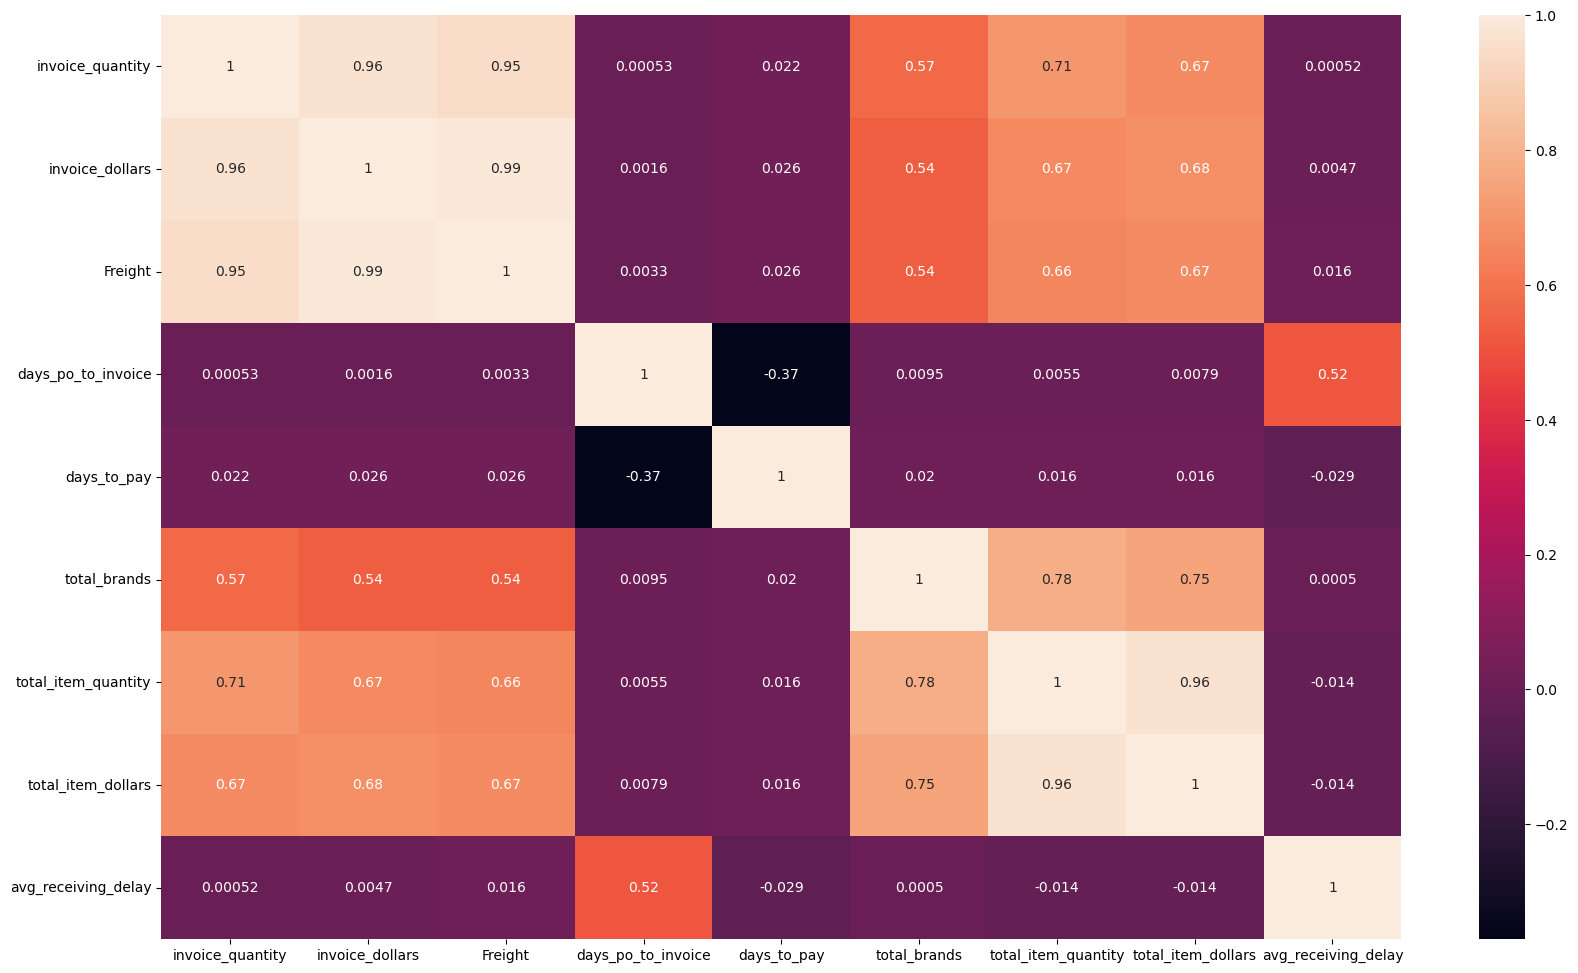

In [24]:
plt.figure(figsize = (20,12))
sns.heatmap(df.iloc[:,1:-1].corr(), annot = True)
plt.show()

In [25]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

To see the difference in the metrics of these both, we will use hypothesis testing. we can also use average out of these. 
For that We'll use T-Test.
T-test we use when we do not have pop-mean and sd and we want to check are there any significant difference between them or not.

In [27]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [28]:
from scipy.stats import ttest_ind
significant_features = []
non_significant_features = []
results = []

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)
        print(metric)
        print({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': 35.42, 'normal_mean': 35.49, 'p_value': 0.692}
total_brands
{'metric': 'total_brands', 'flagged_mean': 42.29, 'normal_mean': 40.82, 'p_value': 0.508}


In [33]:
non_significant_features

['days_to_pay', 'total_brands']

In [37]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [42]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [46]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice',
       'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [48]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0
min,1.0,4.0,0.0,9.0,1.0,4.0
25%,83.0,968.0,5.0,14.0,83.0,968.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0


Here if we see the days_po_to_invoice(max is 23) and avg_receiving_delay (max is 13) in respect to other columns.That's why we need to scaling here.

In [51]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LogisticRegression(random_state = 42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state= 42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state= 42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [54]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test_scaled, y_test, model_name):
    # 1. Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # 2. Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    # 3. Print the results nicely
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    print("Classification Report:")
    print(report)
    print("-" * 40 + "\n")
    
    # 4. Return a dictionary so you can find the "best" model later
    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "model_object": model
    }

In [57]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

--- Logistic Regression Performance ---
Accuracy: 65.73%

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.05      0.09       384

    accuracy                           0.66      1109
   macro avg       0.61      0.51      0.44      1109
weighted avg       0.63      0.66      0.55      1109

----------------------------------------

--- Decision Tree Classifier Performance ---
Accuracy: 82.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       725
           1       0.75      0.73      0.74       384

    accuracy                           0.82      1109
   macro avg       0.81      0.80      0.80      1109
weighted avg       0.82      0.82      0.82      1109

----------------------------------------

--- Random Forest Classifier Performance ---
Accuracy: 88.01%

Classification Report:
         

{'model_name': 'Random Forest Classifier',
 'accuracy': 0.8800721370604148,
 'model_object': RandomForestClassifier(random_state=42)}

In [59]:
model3.feature_importances_

array([0.14760297, 0.15840906, 0.14660377, 0.07598592, 0.20710247,
       0.26429582])

In [61]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by = "importance", ascending = False)

feature_importance

,feature,importance
5,total_item_dollars,0.264296
4,total_item_quantity,0.207102
1,invoice_dollars,0.158409
0,invoice_quantity,0.147603
2,Freight,0.146604
3,days_po_to_invoice,0.075986


In [63]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
       'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state= 42)
model3.fit(X_train_scaled, y_train)

evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

--- Random Forest Classifier Performance ---
Accuracy: 88.55%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.89      1109
   macro avg       0.90      0.85      0.86      1109
weighted avg       0.89      0.89      0.88      1109

----------------------------------------



{'model_name': 'Random Forest Classifier',
 'accuracy': 0.8854824165915239,
 'model_object': RandomForestClassifier(random_state=42)}

In [66]:
# Hyper parameter

from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini','entropy']
}

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid = param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
--- Random Forest Classifier Performance ---
Accuracy: 88.91%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.95      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109

----------------------------------------



{'model_name': 'Random Forest Classifier',
 'accuracy': 0.8890892696122633,
 'model_object': GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
              n_jobs=-1,
              param_grid={'criterion': ['gini', 'entropy'],
                          'max_depth': [None, 4, 5, 6],
                          'min_samples_leaf': [1, 2, 5],
                          'min_samples_split': [2, 3, 5],
                          'n_estimators': [100, 200, 300]},
              scoring=make_scorer(f1_score, response_method='predict'),
              verbose=2)}

In [67]:
from sklearn.metrics import confusion_matrix

In [73]:
cm_tuned = confusion_matrix(grid_search.predict(X_test_scaled), y_test)
print(cm_tuned)

[[712 110]
 [ 13 274]]


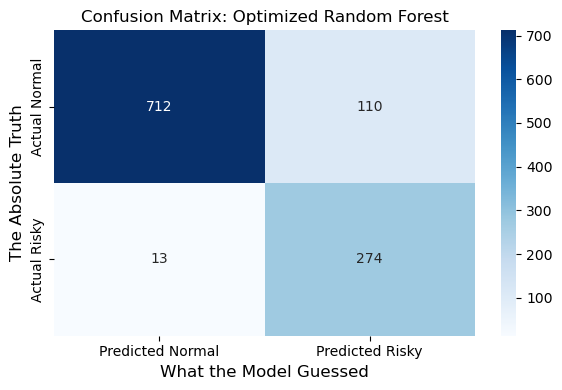

In [83]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Predicted Normal', 'Predicted Risky'], 
            yticklabels=['Actual Normal', 'Actual Risky'])
plt.title('Confusion Matrix: Optimized Random Forest', fontsize=12)
plt.xlabel('What the Model Guessed', fontsize=12)
plt.ylabel('The Absolute Truth', fontsize=12)
plt.tight_layout()
plt.show()

## Model Performance Interpretation

**Overall Accuracy: 88.91%** The model correctly identifies the invoice category (Normal vs. Risky) nearly 89% of the time. While this is a strong headline number, the breakdown below provides the actual business value.

### 1. Precision (Class 1 - Risk): 95%
* **What it means:** When the model flags an invoice as "Risky," it is correct **95% of the time**.
* **Business Impact:** High precision means very few **"False Alarms."** Your accounting team won't waste time investigating invoices that are actually perfectly fine. This builds high trust in the model's alerts.

### 2. Recall (Class 1 - Risk): 71%
* **What it means:** The model successfully identifies **71% of all actual risky invoices** present in the data.
* **Business Impact:** This is our **"Catch Rate."** While we are very accurate when we flag something, we are still missing about 29% of the total risky invoices (labeled as False Negatives). 

### 3. F1-Score (Class 1): 0.82
* **What it means:** The F1-Score is the "Harmonic Mean" (a balanced average) of Precision and Recall.
* **Interpretation:** Since we have very high Precision (0.95) but moderate Recall (0.71), the F1-score of 0.82 gives us a single metric to track our success in balancing "Accuracy vs. Catch Rate."

### 4. Confusion Matrix Analysis
The confusion matrix reveals exactly where the model's predictions landed:

| | Predicted: Normal (0) | Predicted: Risky (1) |
| :--- | :--- | :--- |
| **Actual: Normal (0)** | **712** (Correct) | **13** (False Positive) |
| **Actual: Risky (1)** | **110** (False Negative) | **274** (Correct) |

* **True Negatives (712):** Normal invoices correctly identified.
* **True Positives (274):** Risky invoices correctly caught.
* **False Positives (13):** Normal invoices wrongly flagged (Very Low - Excellent!).
* **False Negatives (110):** Risky invoices that slipped through as "Normal."

---
**Summary Verdict:** This model is **highly trustworthy** but **conservative**. It prioritizes "not being wrong" over "catching everything." For a first deployment, this is ideal as it prevents the team from being overwhelmed by incorrect flags.

In [40]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[707, 109],
       [ 18, 275]], dtype=int64)

In [41]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}

In [42]:
import os
# This mimics what train.py sees
path_to_check = r"../data/inventory.db"
if os.path.exists(path_to_check):
    print("✅ Database found!")
else:
    print("❌ Database NOT found at " + os.path.abspath(path_to_check))

✅ Database found!


In [83]:
import os

# Ensure we are in the script's folder
os.chdir(r"C:\Users\Ahmad Reza\Freight Price Prediction\invoice_flagging")

# Run the training pipeline!
!python train.py

In [85]:
import joblib
from data_preprocessing import load_invoice_data, apply_labels, split_data, scale_features
from modeling_evaluation import evaluate_classifier

# 1. Get the data ready (takes 2 seconds)
df = apply_labels(load_invoice_data())
FEATURES = ['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']
X_train, X_test, y_train, y_test = split_data(df, FEATURES, "flag_invoice")

# 2. Load your saved Translator and Model (Instant)
scaler = joblib.load('models/scaler.pkl')
X_test_scaled = scaler.transform(X_test)
saved_model = joblib.load('models/predict_flag_invoice.pkl')

# 3. Print the results!
evaluate_classifier(saved_model, X_test_scaled, y_test, "Saved Random Forest")


Saved Random Forest Performance
Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       725
           1       0.96      0.71      0.81       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109



In [91]:
# Ensure we are in the script's folder
os.chdir(r"C:\Users\Ahmad Reza\Freight Price Prediction\inference")

# Run the training pipeline!
!python predict_invoice_flag.py


Loading model and predicting risk...

--- Invoice Risk Predictions ---
   invoice_dollars  total_item_dollars  Freight          Status
0           1000.0              1000.0     50.0          Normal
1           5000.0              1000.0    800.0  RISKY (Review)
